In [2]:
# Importar librerias

import pandas as pd
import numpy as np

# Importar librerias necesarias
import statsmodels.api as sm

In [3]:
# Leer el archivo CSV
dataset = pd.read_csv('50_Startups.csv')
dataset.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Ahora necesito seleccionar cual es la variable OBJETIVO y cuales serian las variables que me van a ayudar a hacer la prediccion. Este es un modelo de Aprendizaje Automatico SUPERVISADO porque tengo una variable objetivo (etiqueta)

In [4]:
# Exploremos las columnas del dataset
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='str')

In [6]:
# Seleccionamos las variables dependientes e independientes
y = dataset['Profit'].values
x = dataset[['R&D Spend', 'Administration', 'Marketing Spend']].values

### Dividir el conjunto de datos

Datos de entrenamiento y datos de prueba

In [7]:
# Ahora quiero separar los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test =  train_test_split(x, y, test_size = 0.3, random_state = 0)

In [8]:
x.shape

(50, 3)

In [9]:
x_train.shape

(35, 3)

In [10]:
x_test.shape

(15, 3)

In [11]:
# Descargar el modelo de regresión lineal y crear una instancia del modelo
from sklearn.linear_model import LinearRegression
 
modelo = LinearRegression()
modelo

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# Entrenar el modelo de regresión lineal (con datos de entrenamiento)
modelo.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# realizar predicciones con el modelo entrenado (con datos de prueba)
y_pred = modelo.predict(x_test)

In [14]:
# Comparar los valores reales con los valores predichos
pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

,Actual,Predicted
0,103282.38,104054.442939
1,144259.40,132719.345970
2,146121.95,133640.268309
3,77798.83,72294.769115
4,191050.39,179685.622278
5,105008.31,114508.975720
6,81229.06,66305.230699
7,97483.56,98297.693266
8,110352.25,114277.918949
9,166187.94,169112.360957


In [15]:
# Realizar la evaluación del modelo con métricas de error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))


MAE: 6489.660170486652
MSE: 62240269.84291531
R2 Score: 0.9355188337118217


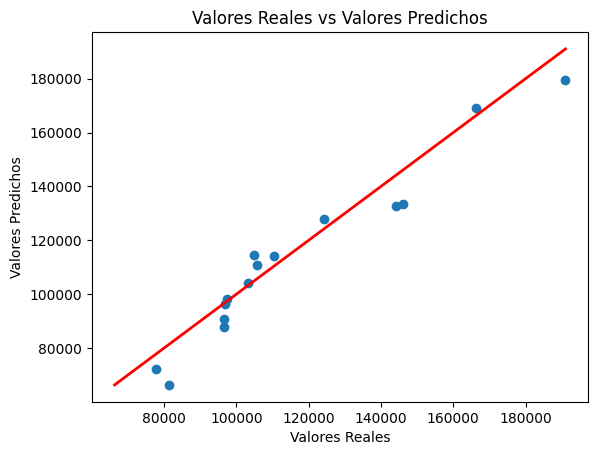

In [18]:
# Dibujar la recta de regresión lineal con los datos de prueba
import matplotlib.pyplot as plt

# Creamos un gráfico de dispersión (scatter plot) para comparar los valores reales y predichos
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs Valores Predichos')

# Calculamos el menor valor entre:
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

# Dibujamos la línea de referencia para comparar los valores reales y predichos
plt.plot(
    [min_val, max_val], # coordenadas x de la línea
    [min_val, max_val], # coordenadas y de la línea
    color='red',        # color de la línea
    linewidth=2         # grosor de la línea
    )
plt.show()

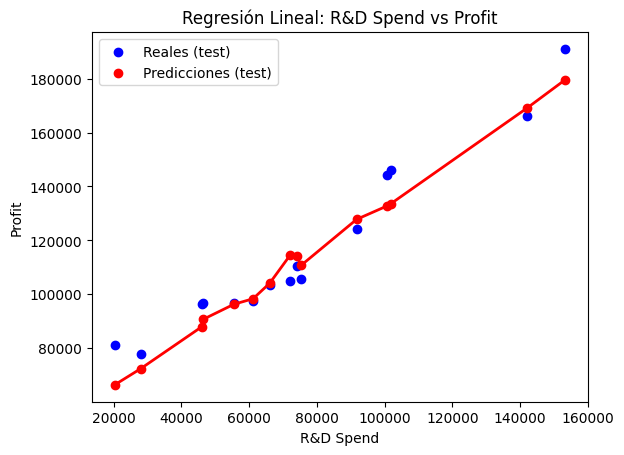

In [22]:
# Comparación correcta sobre el conjunto de prueba
plt.scatter(x_test[:, 0], y_test, color='blue', label='Reales (test)')
plt.scatter(x_test[:, 0], y_pred, color='red', label='Predicciones (test)')

# Para dibujar una línea de predicción ordenada
idx = np.argsort(x_test[:, 0])
plt.plot(x_test[idx, 0], y_pred[idx], color='red', linewidth=2)

plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.title('Regresión Lineal: R&D Spend vs Profit')
plt.legend()
plt.show()

## Opción 2: Usar los datos categoricos

In [ ]:
# importar librerias necesarias
import numpy as np
import pandas as pd

# Ler el archivo CSV
dataset = pd.read_csv('50_Startups.csv')
dataset.head(5)

In [ ]:
# Queremos observar los valores de la columna State
dataset['State'].unique()

In [ ]:
# Convertir la columna 'State' a variables dummy
dataset2 = pd.get_dummies(dataset, columns=['State'], drop_first=True)
dataset2.head(5)

In [ ]:
# Convertir la columna 'State' con OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
dataset3 = ct.fit_transform(dataset)
dataset3
